In [49]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, datetime, timedelta
from matplotlib.dates import MO, TU, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date, timezone
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import numpy as np

plots_filepath = 'plots/june-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo


# Make the data on each chart today's date
def format_date_with_suffix(date_obj):
    day = date_obj.day
    # Determine the ordinal suffix
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return date_obj.strftime(f"%B {day}{suffix}, %Y")

today = datetime.today()
date = format_date_with_suffix(today)

# Color utils
color_palette = {'Hyperliquid':'#09b882','Bold Blue':'#1f1f60', 'Sky Blue':'#6f85ee', 'Solana Purple':'#9945FF','Engage Orange':'#eda024', 'Dark Slate':'#262935', 'Mauve':'#7c1158', 'Yellow':'#ebdc78', 'Green':'#00b7c7', 'Red':'#b30000','Mid Grey':'#54504c','Other Grey':'#a4a2a8', 'Pure Grey': '#808080','Lighter Grey': '#A9A9A9','Lightest Grey': '#D3D3D3','blue 1':'#03045e', 'blue 2':'#0077b6', 'blue 3':'#00b4d8', 'blue 4':'#90e0ef', 'blue 5':'#caf0f8'}
platform_colors = {
        'Felix': color_palette['Sky Blue'],  
        'Hyperliquid': color_palette['Hyperliquid'],  
        'Jupiter': color_palette['Bold Blue'],      
        'dYdX v4': color_palette['Sky Blue'],      
        'ApeX': color_palette['Engage Orange'],         
        'Holdstation': color_palette['Yellow'],  
        'Vertex Protocol': color_palette['Green'], 
        'GMX': color_palette['Red'],          
        'dYdX v3': color_palette['Dark Slate'],      
        'Drift Protocol': color_palette['Mauve'],
        'RabbitX': color_palette['Mid Grey'],           
        'dYdX': color_palette['Dark Slate'],
        'Gains Network': color_palette['Mauve'],
        'KTX Finance': color_palette['Yellow'],
        'RabbitX': color_palette['Pure Grey'],
        'Aevo': color_palette['Lighter Grey'],
        'Other': color_palette['Other Grey'],
        'Hyperliquid Perps': color_palette['Hyperliquid'],
        'Jupiter Perpetual Exchange': color_palette['Bold Blue'],
        'Vertex Perps': color_palette['Green'],
        'Apex Omni': color_palette['Engage Orange'],
        'MYX Finance': color_palette['Yellow'],
        'edgeX': color_palette['Red'],
        'Ostium': color_palette['Mauve'],
        'RabitX': color_palette['Yellow'],
        'Aark Digital': color_palette['Dark Slate'],
        'dYdX (V3+V4)': color_palette['Sky Blue']
    }

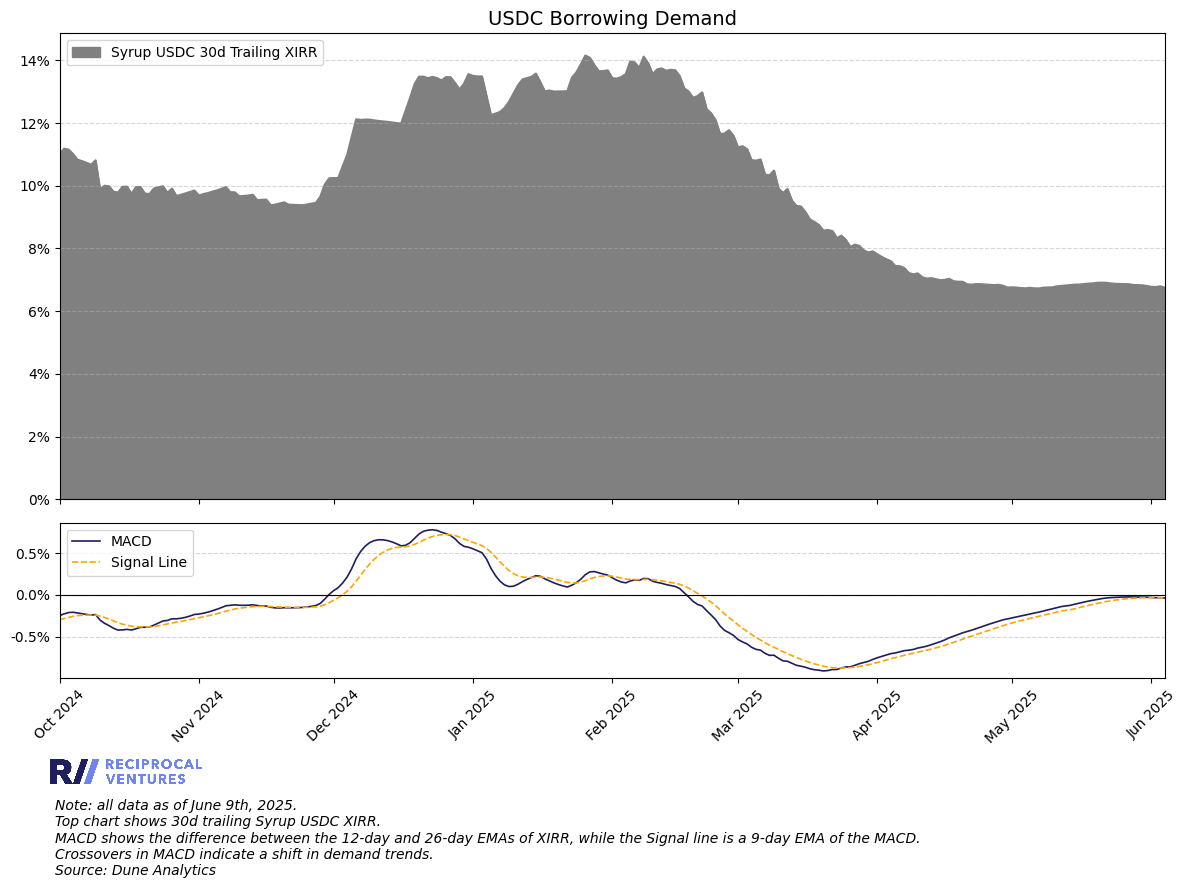

In [50]:
# Load the JSON file
with open("raw-data/dune-raw-data/dune_maple-xirr.json", "r") as f:
    raw_data = json.load(f)

# Extract relevant rows only for "Syrup USDC"
entries = raw_data["result"]["rows"]
syrup_usdc_rows = [e for e in entries if e["pool_name"] == "Syrup USDC"]

# Convert to DataFrame
df = pd.DataFrame(syrup_usdc_rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df['percent_xirr'] = df['trailing_xirr'] * 100

# Compute EMA and MACD
def compute_ema(values, period):
    ema = [None] * len(values)
    multiplier = 2 / (period + 1)

    # Find first index with enough non-None values
    valid_start = next((i for i in range(len(values)) if values[i] is not None), None)
    if valid_start is None or valid_start + period > len(values):
        return ema  # not enough data

    # Initialize EMA at first valid point
    ema[valid_start + period] = sum(values[valid_start:valid_start + period]) / period

    for i in range(valid_start + period + 1, len(values)):
        if values[i] is not None and ema[i - 1] is not None:
            ema[i] = (values[i] - ema[i - 1]) * multiplier + ema[i - 1]

    return ema

# Extract values
dates = df["date"].tolist()
percent_xirrs = df['percent_xirr'].tolist()

# Calculate EMAs and MACD
ema_12 = compute_ema(percent_xirrs, 12)
ema_26 = compute_ema(percent_xirrs, 26)
macd = [e12 - e26 if e12 is not None and e26 is not None else None for e12, e26 in zip(ema_12, ema_26)]

# Clean None values from MACD before computing signal line
macd_cleaned = [v if v is not None else 0 for v in macd]
signal = compute_ema(macd_cleaned, 9)

# Add back to the dataframe
df['ema_12'] = ema_12
df['ema_26'] = ema_26
df['macd'] = macd_cleaned
df['signal'] = signal

# Filter to cutoff date
df = df[df["date"] >= '2024-10-01'].reset_index(drop=True)

# Create figure with two subplots (main + MACD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Area chart for XIRR
ax1.fill_between(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], alpha=1, label="Syrup USDC 30d Trailing XIRR")
ax1.plot(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], linewidth=1.5)
ax1.set_title("USDC Borrowing Demand", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")
ax1.set_ylim(bottom=0)

# MACD Indicator
# MACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD. Crossovers may indicate shifts in APY momentum.
ax2.plot(df['date'], df['macd'], label="MACD", color="#1f1f60", linewidth=1.2)
ax2.plot(df['date'], df['signal'], label="Signal Line", color="orange", linestyle="--", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# X-axis formatting
ax1.margins(x=0)
ax2.margins(x=0)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Format y-axis on main chart as %
def percent_formatter_no_decimal(x, pos):
    return f"{x:.0f}%"
def percent_formatter(x, pos):
    return f"{x:.1f}%"
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter_no_decimal))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter))

# Add Reciprocal logo and source note
add_logo(ax2, position=(0.06, -0.6))
plt.figtext(0.05, -0.1, f"Note: all data as of {date}.\nTop chart shows 30d trailing Syrup USDC XIRR.\nMACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD.\nCrossovers in MACD indicate a shift in demand trends.\nSource: Dune Analytics", ha='left', fontsize=10, style='italic')

# Save and show
imgtitle = "usdc-30d-trailing-xirr-and-macd"
plt.tight_layout()
save_path = os.path.join("plots/june-25/", f"{imgtitle}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [51]:
# Function to plot top protocols by fees or revenue
def top_n_protocols_by_category(metric, category, start_date, end_date, n):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#191F98',
                    '#313EA5',
                    '#4A5DB2',
                    '#637BBF',
                    '#7C9ACC',
                    '#94B9D9',
                    '#ADD8E6',
                    '#333333',
                    '#494949',
                    '#5F5F5F',
                    '#757575',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', f'{metric}']
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset]]
        raw_df[asset] = raw_df[asset].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0, inplace=True)
    
        # Iterate coutner by 1
        counter += 1
        
    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        protocols.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )

    # Filter asset by desired numbe of protocols
    asset_list = asset_list[:n]

    if n < counter:
        counter = n

    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'Top {counter} {category} by Daily Fees')
    if metric == 'dailyRevenue':
        ax.set_title(f'Top {counter} {category} by Daily Revenue')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category}-{metric}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

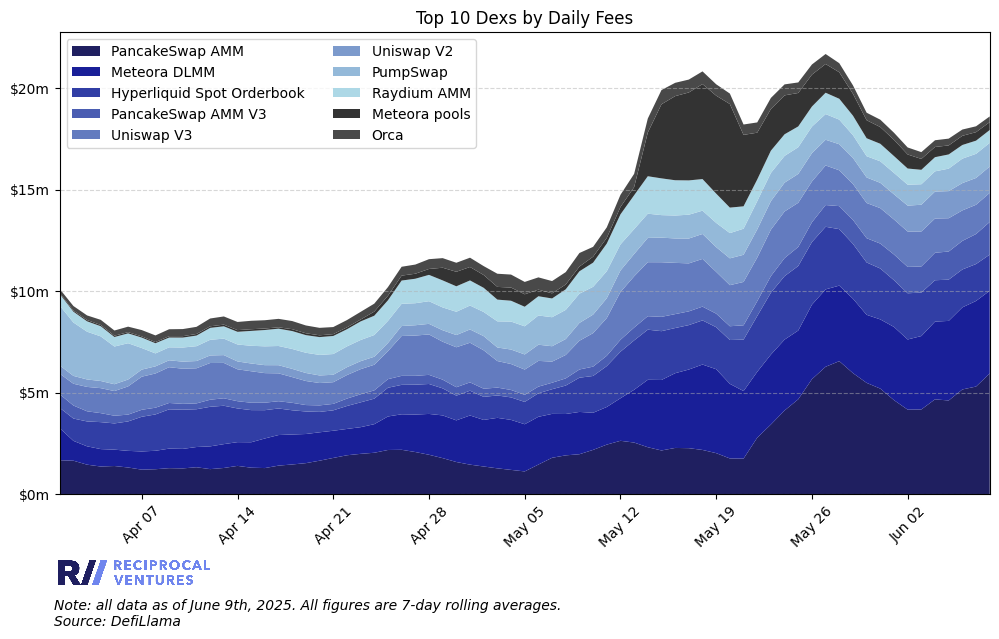

           date  PancakeSwap AMM  Meteora DLMM  Hyperliquid Spot Orderbook  \
1849 2025-06-04     4.665125e+06  3.830480e+06                2.038586e+06   
1850 2025-06-05     4.607802e+06  3.922494e+06                2.032775e+06   
1851 2025-06-06     5.151861e+06  4.044444e+06                1.868835e+06   
1852 2025-06-07     5.295432e+06  4.217418e+06                1.819220e+06   
1853 2025-06-08     5.939125e+06  4.073752e+06                1.783056e+06   

        Uniswap V3  Meteora pools    Uniswap V2      PumpSwap  \
1849  1.688429e+06  503978.857143  1.327805e+06  9.958556e+05   
1850  1.641107e+06  443934.142857  1.336522e+06  1.106943e+06   
1851  1.503796e+06  452489.714286  1.344721e+06  1.206193e+06   
1852  1.442659e+06  419046.714286  1.320835e+06  1.188413e+06   
1853  1.433487e+06  388587.857143  1.296996e+06  1.166402e+06   

      PancakeSwap AMM V3    Raydium AMM           Orca  Aerodrome Slipstream  \
1849        1.353862e+06  697867.428571  331140.428571      

In [52]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'Dexs'
start_date = '2025-04-01'
end_date = today
n = 10 # number of protocols to show, max is number pulled down in the raw data

top_n_protocols_by_category(metric, category, start_date, end_date, n)

In [53]:
# Function compare fees or revenue for a subsect of assets
def compare_assets(metric, category, breakout_assets, start_date, end_date):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    df_master = None

    compare_dict = {}

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        if asset in breakout_assets:
            compare_dict[raw_id] = asset
            with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
                data = json.load(f)
            
            # Select only the two real keys, then rename
            raw_df = pd.DataFrame(
                data['totalDataChart'],
                columns=['date', f'{metric}']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                f'{metric}': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
        
            # Merge dataframes
            df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
            df_master.fillna(0, inplace=True)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    print(df_master.tail(5))
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        compare_dict.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=3)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. \nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'{category}: Daily Fees Comparison')
    if metric == 'dailyRevenue':
        ax.set_title(f'{category}: Daily Revenue Comparison')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{category}-{metric}-stacked.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

          date  Hyperliquid Spot Orderbook   PumpSwap  Raydium AMM      Orca
961 2025-06-04                   1798068.0   972058.0     764671.0  307721.0
962 2025-06-05                   3093273.0  1827299.0     734083.0  424618.0
963 2025-06-06                   1869461.0  1660320.0     614103.0  261754.0
964 2025-06-07                    918833.0   929848.0     452261.0  154783.0
965 2025-06-08                    820745.0   828612.0     432325.0  176619.0


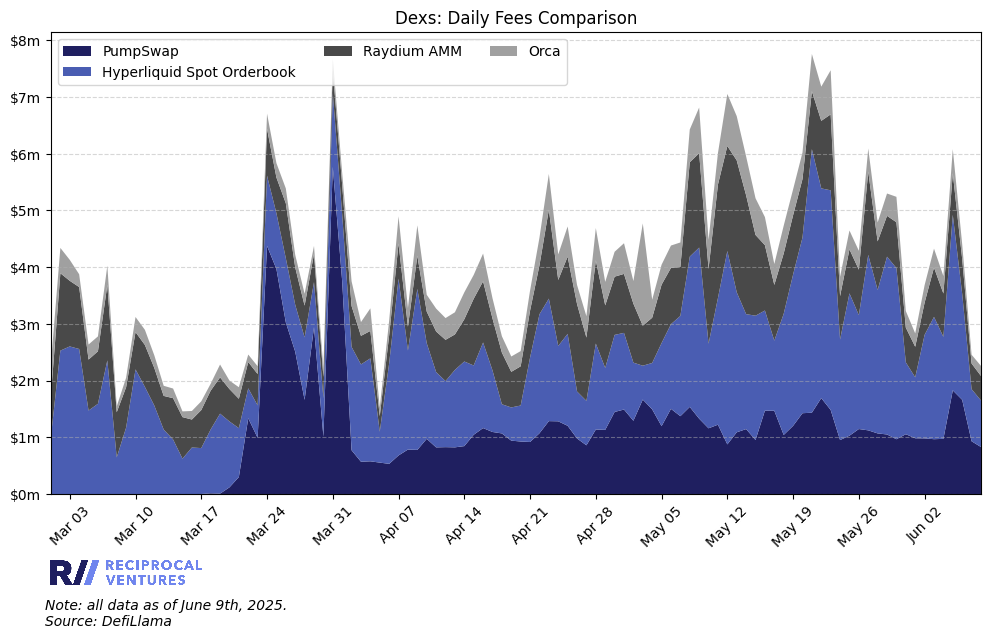

          date  Hyperliquid Spot Orderbook   PumpSwap  Raydium AMM      Orca
961 2025-06-04                   1798068.0   972058.0     764671.0  307721.0
962 2025-06-05                   3093273.0  1827299.0     734083.0  424618.0
963 2025-06-06                   1869461.0  1660320.0     614103.0  261754.0
964 2025-06-07                    918833.0   929848.0     452261.0  154783.0
965 2025-06-08                    820745.0   828612.0     432325.0  176619.0


In [54]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'Dexs'
start_date = '2025-03-01'
end_date = today
breakout_assets = ['Hyperliquid Spot Orderbook', 'PumpSwap', 'Raydium AMM', 'Orca']

compare_assets(metric, category, breakout_assets, start_date, end_date)

In [55]:
# Function compare fees or revenue for a subsect of assets
def compare_assets(metric, category, breakout_assets, start_date, end_date):
    with open(f'raw-data/defillama-raw-data/{metric}_data/top-protocols-{category}.json', 'r') as f:
        protocols = json.load(f)
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    df_master = None

    compare_dict = {}

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for raw_id, asset in protocols.items():
        if asset in breakout_assets:
            compare_dict[raw_id] = asset
            with open(f'raw-data/defillama-raw-data/{metric}_data/{raw_id}.json') as f:
                data = json.load(f)
            
            # Select only the two real keys, then rename
            raw_df = pd.DataFrame(
                data['totalDataChart'],
                columns=['date', f'{metric}']
            )
            raw_df.rename(columns={
                'date': 'timestamp',
                f'{metric}': asset
            }, inplace=True)
            raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
            raw_df = raw_df[['date', asset]]
            raw_df[asset] = raw_df[asset].rolling(window=7).mean()
        
            # Merge dataframes
            df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
            df_master.fillna(0, inplace=True)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    print(df_master.tail(5))
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the asset names by descending value on that last row
    asset_list = sorted(
        compare_dict.values(),
        key=lambda asset: last_row[asset],
        reverse=True
    )
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, asset in enumerate(asset_list):
        ax.plot(
            df_master['date'],
            df_master[asset],
            color = asset_colors[i],
            linewidth = 2,
            label=asset
        )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000:.0f}m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'{category}: Daily Fees Comparison')
    if metric == 'dailyRevenue':
        ax.set_title(f'{category}: Daily Revenue Comparison')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{category}-{metric}-line.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

          date  Hyperliquid Spot Orderbook      PumpSwap    Raydium AMM  \
961 2025-06-04                2.038586e+06  9.958556e+05  697867.428571   
962 2025-06-05                2.032775e+06  1.106943e+06  699881.285714   
963 2025-06-06                1.868835e+06  1.206193e+06  672063.428571   
964 2025-06-07                1.819220e+06  1.188413e+06  649073.714286   
965 2025-06-08                1.783056e+06  1.166402e+06  633790.142857   

              Orca  
961  331140.428571  
962  335515.000000  
963  308949.857143  
964  289320.000000  
965  280902.000000  


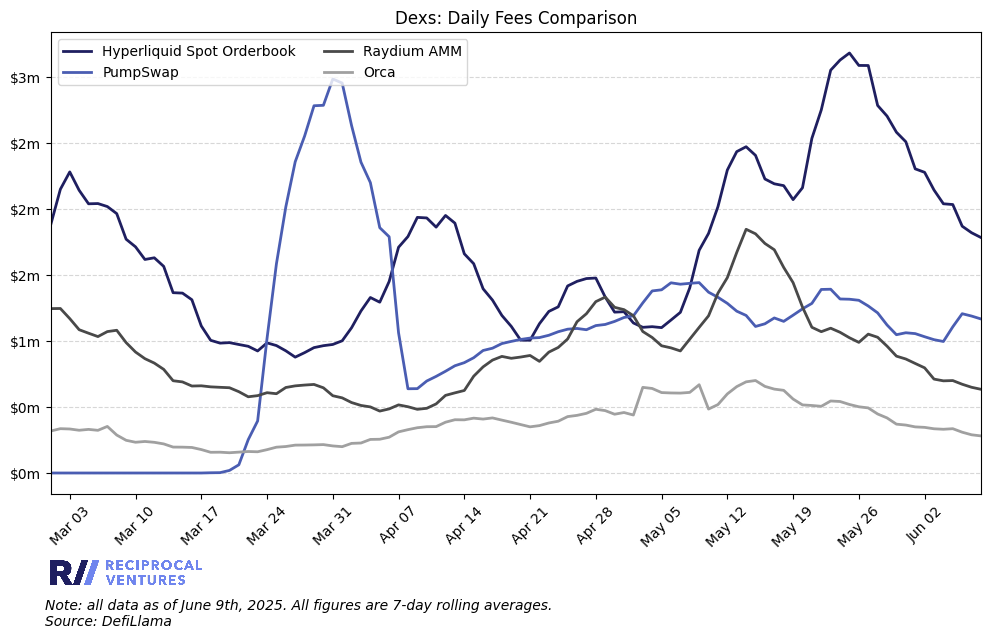

          date  Hyperliquid Spot Orderbook      PumpSwap    Raydium AMM  \
961 2025-06-04                2.038586e+06  9.958556e+05  697867.428571   
962 2025-06-05                2.032775e+06  1.106943e+06  699881.285714   
963 2025-06-06                1.868835e+06  1.206193e+06  672063.428571   
964 2025-06-07                1.819220e+06  1.188413e+06  649073.714286   
965 2025-06-08                1.783056e+06  1.166402e+06  633790.142857   

              Orca  
961  331140.428571  
962  335515.000000  
963  308949.857143  
964  289320.000000  
965  280902.000000  


In [56]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
category = 'Dexs'
start_date = '2025-03-01'
end_date = today
breakout_assets = ['Hyperliquid Spot Orderbook', 'PumpSwap', 'Raydium AMM', 'Orca']

compare_assets(metric, category, breakout_assets, start_date, end_date)